In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [14]:
img = np.zeros((200,200),dtype=np.uint8)
cv2.circle(img,(100,100),70,255,-1)
noisy = img.copy()
noise = np.random.random(img.shape)
noisy[noise < 0.2] = 0
noisy[noise > 0.98] = 255

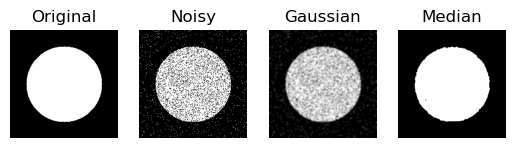

In [15]:
gaussian = cv2.GaussianBlur(noisy,(5,5),0)
median = cv2.medianBlur(noisy,5)
titles = ['Original', 'Noisy', 'Gaussian','Median']
images = [img,noisy,gaussian,median]

for i in range(4):
    plt.subplot(1,4,i+1)
    plt.imshow(images[i],cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

In [16]:
def psnr(a,b):
    mse = np.mean((a-b)**2)
    return 20*np.log10(255.0/np.sqrt(mse)) if mse else float('inf')

print(f"Gaussian PSNR : {round(psnr(img,gaussian),2)}")
print(f"median : {round(psnr(img,median),2)}")

Gaussian PSNR : 30.93
median : 69.92
